In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import glob 
import psrsigsim as pss

%matplotlib inline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

2026-04-16 10:49:34.203 | DEBUG    | pint.polycos:add_polyco_file_format:629 - Registering Polyco format 'tempo' with mode='rw'


In [2]:
# modified PsrSigSim (now on my own fork) to remove early noise injection
# reproduced Tyler's simulation by generating high-resolution data then downsampling
# --- the combination of pulse period and DM is sensitive to small perturbations -- make sure we have both numbers as precise as possible
# scintillation three ways:
# --- baseband domain (possible with PsrSigSim, still working on this)
# --- global application from secondary spectrum (demo below)
# --- local application from NE2025 statistics (discussed with Jim last week)

# pulsar gating: TEMPO2 demo here: https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/pulsar_gating_tutorial.html
# --- TEMPO2 --> PINT integration in PsrSigSim?

In [2]:
# Define our signal variables.
f0 = 125 # center observing frequecy in MHz
bw = 150 # observation MHz
Nf = 256 # number of frequency channels
f_samp = 0.0001 # sample rate of data in MHz (here 0.6554 ms for size purposes)
# Now we define our signal
signal_1 = pss.signal.FilterBankSignal(fcent = f0, bandwidth = bw, Nsubband=Nf, sample_rate=f_samp, fold = False)
# We define the Guassian profile
gauss_prof = pss.pulsar.GaussProfile(peak = 0.5, width = 0.05, amp = 1.0)
# We want to use 2048 phase bins and just one frequency channel for this test.
gauss_prof.init_profiles(2048, Nchan = 1)

In [3]:
nfavg = bw//0.122
print(nfavg)

1229.0


In [4]:
150/256

0.5859375

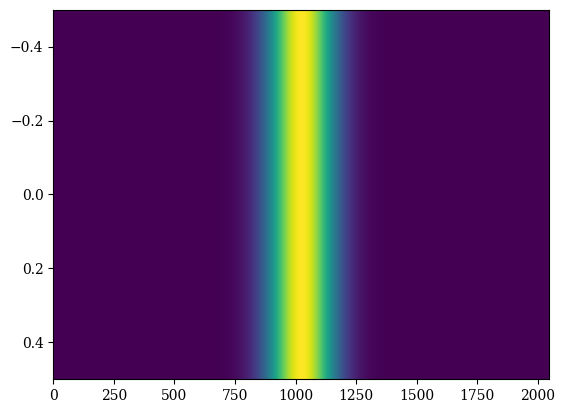

In [5]:
plt.imshow(gauss_prof.profiles, aspect='auto')
plt.show()

In [6]:
# Define the values needed for the puslar
period = 1.2 # pulse period of our simulated pulsar, here one second
Smean = 10.0 # The mean flux of the pulsar, here 10.0 Jy (note that this is very bright for a pulsar)
psr_name = "J0630-2834" # The name of our simulated pulsar
# psr_name_b = 'B0628-28'
# Now we define the pulsar
pulsar_1 = pss.pulsar.Pulsar(period, Smean, profiles=gauss_prof, name = psr_name)

In [7]:
# Define the dispersion measure
dm = 34.0 # pc cm^-3
# And define the ISM object, note that this class takes no initial arguements
ism_1 = pss.ism.ISM()

In [8]:
# define the observation length
obslen = 3600.0 # seconds
pulsar_1.make_pulses(signal_1, tobs = obslen)
ism_1.disperse(signal_1, dm)

98% dispersed in 2.491 seconds.

In [9]:
print(signal_1.tobs.value)

3600.0


In [ ]:
print(signal_1.data.shape)


(256, 360000)


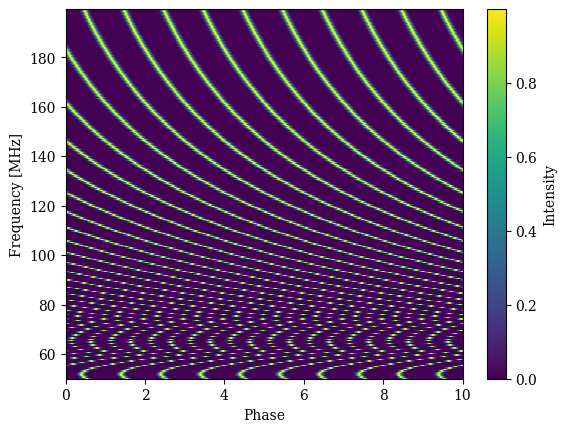

In [10]:
phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
plt.imshow(signal_1.data, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value])
plt.ylabel("Frequency [MHz]")
plt.xlabel("Phase")
plt.colorbar(label = "Intensity")
plt.xlim(0,10)

plt.show()
plt.close()

In [11]:
print(signal_1.data.shape)

(256, 360000)


In [12]:
def downbin(a, phases, fbin=0.122, tbin=9.6636):
    nf = (a.dat_freq[-1].value-a.dat_freq[0].value)/fbin+1
    nt = a.tobs.value/tbin
    nfpb = len(a.data)/nf
    ntpb = len(a.data[0])/nt
    print(nf, nfpb, nt, ntpb)
    arr = a.data.reshape(int(round(nf)), int(round(nfpb)), int(round(nt)), int(round(ntpb)))
    arr = np.average(arr, axis=3)
    arr = np.average(arr, axis=1)
    return arr

In [13]:
print(bw/Nf)
print(bw, Nf)

0.5859375
150 256


In [14]:
256*360*1000

92160000

In [15]:
phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
a = downbin(signal_1, phases, fbin=0.5859375, tbin=10)

256.0 1.0 360.0 1000.0


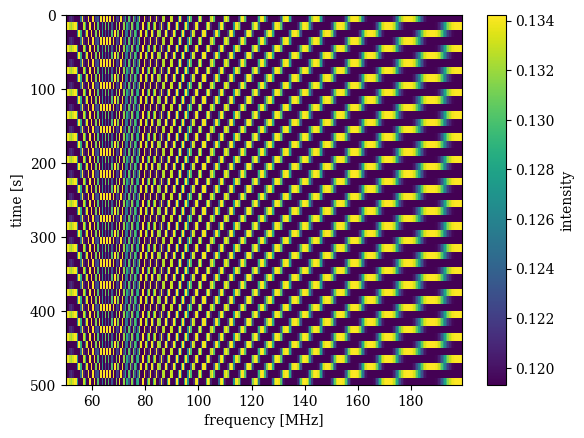

In [18]:
plt.imshow(a.T[:50], aspect = 'auto', interpolation='none', origin = 'upper', \
           extent = [signal_1.dat_freq[0].value, signal_1.dat_freq[-1].value, 500, 0],  cmap='viridis')
plt.xlabel('frequency [MHz]')
plt.ylabel('time [s]')
plt.colorbar(label = 'intensity')
#plt.xlim(100,120)
#plt.ylim(0,500)
#np.save('DMbeat_spectrum.npy', a.T)

plt.show()
plt.close()

In [1]:
from src.dmbeat import *

dspec = dmbeat(45, 250, 1.22, 10, 1000)
plt.imshow(dspec, aspect = 'auto', interpolation='none', origin = 'upper', cmap='viridis')
#plt.xlabel('frequency [MHz]')
#plt.ylabel('time [s]')
plt.colorbar(label = 'intensity')
plt.show()
plt.close()

2026-04-16 11:48:04.913 | DEBUG    | pint.polycos:add_polyco_file_format:629 - Registering Polyco format 'tempo' with mode='rw'


Center frequency is 147.5 MHz.
Total bandwidth is 205 MHz.
There will be 336 frequency channels.
Sample rate is 0.0007999999999999999 MHz.


IndexError: list index out of range

In [ ]:
### TEST SECONDARY SPECTRA

In [98]:
sec_spec = np.zeros((1638, 12000))
print(sec_spec.shape)
# parabola:
# y = a0*(x-x0)**2 + b0*(x-x0)
x0 = len(sec_spec[0])/2
a0 = 10
b0 = 0.1
for row in range(len(sec_spec)):
    if row%100 == 0:
        print(row)
    for col in range(len(sec_spec[0])):
        # if (row%100 == 0) & (col%1000 == 0):
        #     print(f'  {col}')
        yval = a0*(col-x0)**2 + b0*(col-x0)
        if np.abs(row - yval) < 100:
            sec_spec[row, col] += 1
        if np.abs(row - yval) < 50:
            sec_spec[row, col] += 1

(1638, 12000)
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600


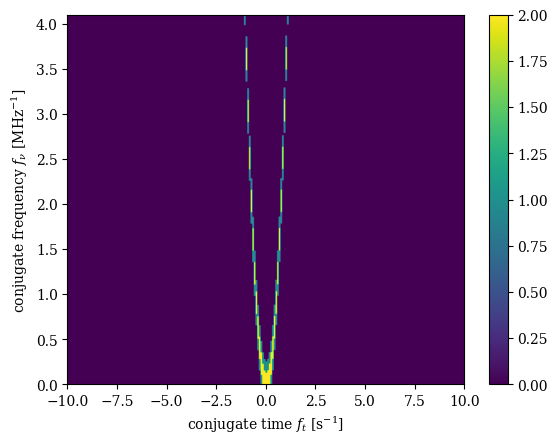

In [99]:
cfb = np.fft.rfftfreq(1638, 0.122) # units of seconds
ctb = np.fft.rfftfreq(12000, 1/2000)-500
plt.imshow(sec_spec, aspect='auto', origin='lower', extent=[min(ctb), max(ctb), min(cfb), max(cfb)])
plt.colorbar()
plt.xlim(-10, 10)
plt.xlabel(r'conjugate time $f_t$ [s$^{-1}$]')
plt.ylabel(r'conjugate frequency $f_\nu$ [MHz$^{-1}$]')
plt.show()

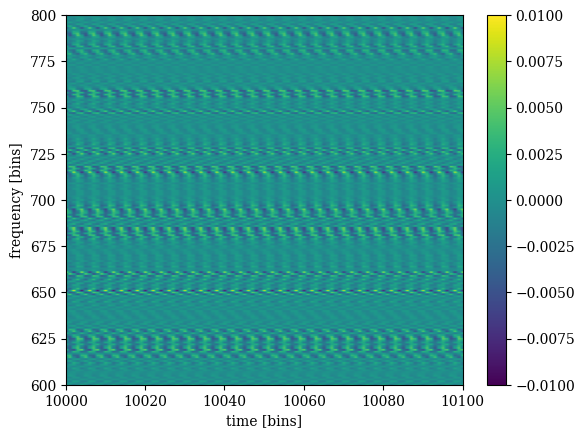

In [112]:
plt.imshow(np.fft.irfft2(sec_spec*10000), aspect='auto', origin='lower',
           vmin=-0.01, vmax=0.01
           )
plt.colorbar()
plt.xlim(10000, 10100)
plt.xlabel('time [bins]')
plt.ylim(600, 800)
plt.ylabel('frequency [bins]')
plt.show()

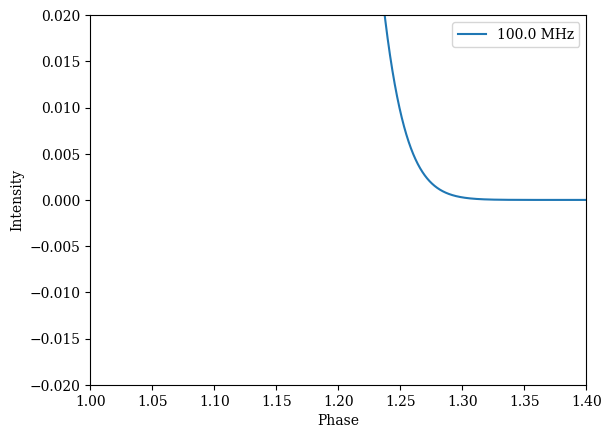

In [11]:
# Get the phases of the pulse
phases = np.linspace(0, obslen/period, len(signal_1.data[0,:]))
# Plot just the pulses in the first frequency channels
plt.plot(phases, signal_1.data[0,:], label = signal_1.dat_freq[0])
plt.ylabel("Intensity")
plt.xlabel("Phase")
plt.legend(loc = 'best')
plt.xlim(1,1.4)
plt.ylim(-0.02, 0.02)
plt.show()
plt.close()